# Delta策略模块演示

这个notebook演示如何使用delta模块进行策略研究和回测。

In [180]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
import sys
sys.path.append('/home/jovyan/base_demo')
import base_tool

import pandas as pd
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', 65)

## 导入delta模块

In [182]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')
from delta import *

## 设置参数（包含自适应参数）

In [ ]:
instrument_id = '518880'
trade_ymd = '20260319'

param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_adaptive',
    'stride': 1,

    'short_window': 60,
    'long_window': 300,
    'y_window': 300,

    'open_threshold': 2,  
    'open_confidence': 0,  

    'standard_num': 1000,

    'atr_multiplier': 4,
    'vol_window': 300,
    
    'gamma': 0.05,
    'exit_confirm_bars': 5,
    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

## 获取交易日数据

In [208]:
trade_dates = get_trade_dates()
print(f"总交易日数量: {len(trade_dates)}")
print(f"交易日范围: {trade_dates[0]} ~ {trade_dates[-1]}")

# 方法1: 使用天数分割（原来的方法）
# train_dates, valid_dates, test_dates = split_dates(trade_dates,45,15,17)

# 方法2: 使用日期范围分割（新的灵活方法）
train_dates, valid_dates, test_dates = split_dates_by_range(
    trade_dates,
    train_start="20260101",  # 训练集开始日期
    train_end="20260228",    # 训练集结束日期
    valid_start="20251201",  # 验证集开始日期
    valid_end="20251201",    # 验证集结束日期
    test_start="20251201",   # 测试集开始日期
    test_end="20251231"      # 测试集结束日期
)
'''train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    
    trade_dates,
    test_days_min=23,
    valid_days=1,
    random_seed=6262,
    shuffle=True)'''

总交易日数量: 57
交易日范围: 20251201 ~ 20260227
训练集: 20260105 ~ 20260227 (34天)
验证集: 20251201 ~ 20251201 (1天)
测试集: 20251201 ~ 20251231 (23天)


'train_dates, valid_dates, test_dates = trade_dates,valid_dates,test_dates = split_dates_randomly(    \n    trade_dates,\n    test_days_min=23,\n    valid_days=1,\n    random_seed=6262,\n    shuffle=True)'

## 生成训练数据

In [209]:
print("生成训练集样本...")
X_train, y_train , feature_names= samples_from_dates(train_dates, instrument_id, param_dict, create_feature, create_y)
print(f"训练集样本: X={X_train.shape}, y={y_train.shape}")

生成训练集样本...
20260105: 产生 781 个样本
20260106: 产生 767 个样本
20260107: 产生 798 个样本
20260108: 产生 819 个样本
20260109: 产生 755 个样本
20260112: 产生 754 个样本
20260113: 产生 779 个样本
20260114: 产生 812 个样本
20260115: 产生 789 个样本
20260116: 产生 753 个样本
20260119: 产生 752 个样本
20260120: 产生 810 个样本
20260121: 产生 794 个样本
20260122: 产生 748 个样本
20260123: 产生 781 个样本
20260126: 产生 858 个样本
20260127: 产生 791 个样本
20260128: 产生 802 个样本
20260129: 产生 812 个样本
20260130: 产生 884 个样本
20260202: 产生 757 个样本
20260203: 产生 833 个样本
20260204: 产生 812 个样本
20260205: 产生 834 个样本
20260206: 产生 839 个样本
20260209: 产生 814 个样本
20260210: 产生 781 个样本
20260211: 产生 745 个样本
20260212: 产生 737 个样本
20260213: 产生 772 个样本
20260224: 产生 752 个样本
20260225: 产生 777 个样本
20260226: 产生 774 个样本
20260227: 产生 745 个样本
训练集样本: X=(26811, 12), y=(26811,)


In [210]:
print("生成验证集样本...")
X_valid, y_valid , __= samples_from_dates(valid_dates, instrument_id, param_dict, create_feature, create_y)
print(f"验证集样本: X={X_valid.shape}, y={y_valid.shape}")

生成验证集样本...
20251201: 产生 805 个样本
验证集样本: X=(805, 12), y=(805,)


In [211]:
print("生成测试集样本...")
X_test, y_test ,__= samples_from_dates(test_dates, instrument_id, param_dict, create_feature, create_y)
print(f"测试集样本: X={X_test.shape}, y={y_test.shape}")

生成测试集样本...
20251201: 产生 805 个样本
20251202: 产生 794 个样本
20251203: 产生 791 个样本
20251204: 产生 778 个样本
20251205: 产生 813 个样本
20251208: 产生 803 个样本
20251209: 产生 858 个样本
20251210: 产生 754 个样本
20251211: 产生 807 个样本
20251212: 产生 766 个样本
20251215: 产生 809 个样本
20251216: 产生 865 个样本
20251217: 产生 808 个样本
20251218: 产生 787 个样本
20251219: 产生 769 个样本
20251222: 产生 821 个样本
20251223: 产生 857 个样本
20251224: 产生 803 个样本
20251225: 产生 821 个样本
20251226: 产生 822 个样本
20251229: 产生 821 个样本
20251230: 产生 799 个样本
20251231: 产生 794 个样本
测试集样本: X=(18545, 12), y=(18545,)


In [212]:
X_valid = X_test
y_valid = y_test

## 训练模型

In [213]:
model = train_model(X_train, y_train, X_valid, y_valid, param_dict , feature_names)

训练 xgboost 模型...
[0]	validation_0-logloss:0.69291
[100]	validation_0-logloss:0.66810
[200]	validation_0-logloss:0.65175
[300]	validation_0-logloss:0.63974
[400]	validation_0-logloss:0.63461
[500]	validation_0-logloss:0.62858
[600]	validation_0-logloss:0.62322
[700]	validation_0-logloss:0.62119
[800]	validation_0-logloss:0.61936
[900]	validation_0-logloss:0.61919
[1000]	validation_0-logloss:0.61718
[1100]	validation_0-logloss:0.61623
[1200]	validation_0-logloss:0.61657
[1300]	validation_0-logloss:0.61608
[1400]	validation_0-logloss:0.61613
[1500]	validation_0-logloss:0.61552
[1600]	validation_0-logloss:0.61570
[1700]	validation_0-logloss:0.61581
[1800]	validation_0-logloss:0.61638
[1900]	validation_0-logloss:0.61662
[1999]	validation_0-logloss:0.61925
阈值优化完成: Best Threshold=0.5240, F0.5=0.4569

特征重要性（前10个）:
volatility    0.195772
alpha_07      0.134815
volume        0.092080
num_trades    0.089866
alpha_04      0.088895
spread        0.079625
WAMP          0.077703
alpha_05      0.05401

In [214]:
# 保存模型
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
joblib.dump(model, model_path)
print(f"模型已保存到: {model_path}")

模型已保存到: /home/jovyan/work/model/delta_518880.pkl


## 测试模型

测试集准确率: 0.6472

分类报告:
              precision    recall  f1-score   support

           0       0.79      0.67      0.73     13013
           1       0.43      0.59      0.50      5532

    accuracy                           0.65     18545
   macro avg       0.61      0.63      0.61     18545
weighted avg       0.69      0.65      0.66     18545


PR曲线AUC: 0.4463
平均精度 (AP): 0.4465

预测概率统计:
  均值: 0.4460
  标准差: 0.1954
  最小值: 0.0072
  25%分位数: 0.3152
  中位数: 0.4691
  75%分位数: 0.6059
  最大值: 0.8725

按真实标签分组的预测概率统计:
  标签0 (负类): 均值=0.4089, 标准差=0.1975
  标签1 (正类): 均值=0.5333, 标准差=0.1594


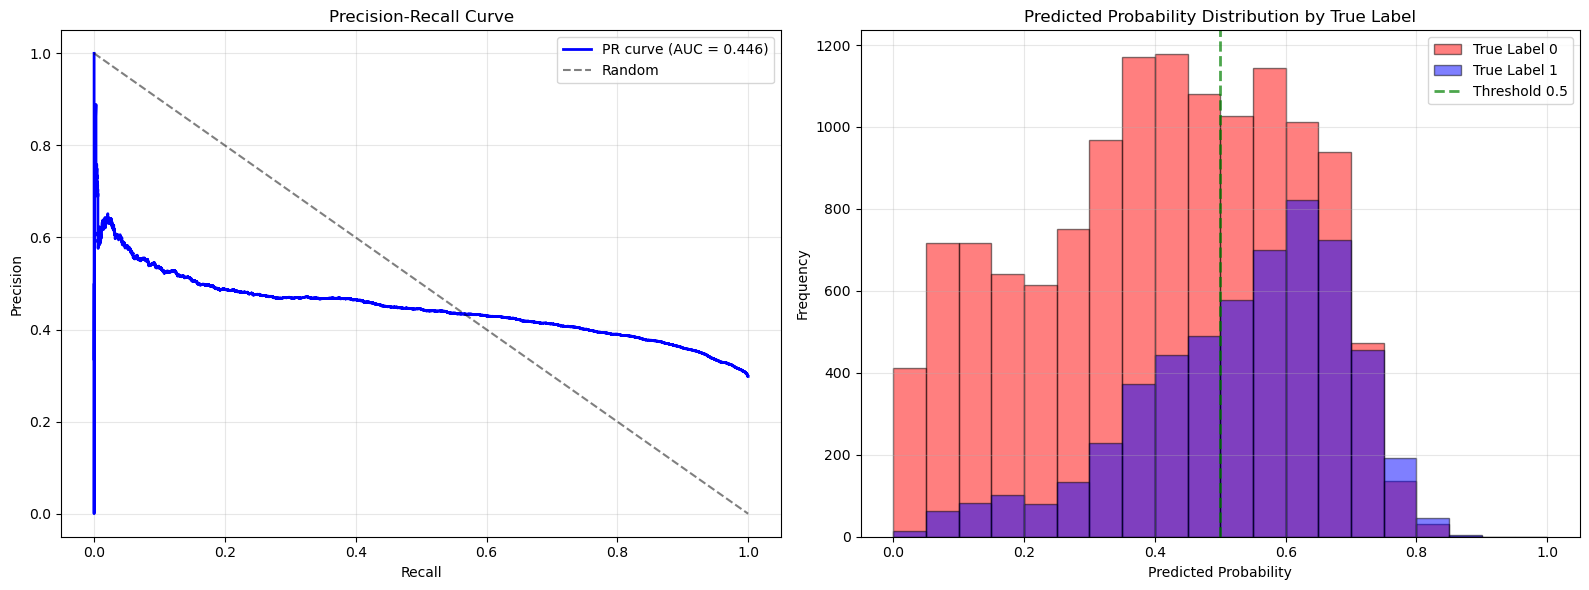

In [215]:
accuracy = evaluate_model(model, X_test, y_test, show_plots=True)

## 创建策略实例

In [230]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
strategy = StrategyDemo(model_path, param_dict)
print(f"策略已创建: {strategy.name}")

策略已创建: delta_v1_adaptive


## 使用backtesting工具进行回测

In [ ]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 518880 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-190] 日期 20251209 完成 | 盈亏: -4.90 | 成交: 24次 | 胜率: 16.7% | 平均持仓: 479.6快照
[SpawnPoolWorker-191] 日期 20251225 完成 | 盈亏: 0.40 | 成交: 17次 | 胜率: 35.3% | 平均持仓: 703.1快照
[SpawnPoolWorker-192] 日期 20251217 完成 | 盈亏: -1.20 | 成交: 19次 | 胜率: 36.8% | 平均持仓: 445.3快照
[SpawnPoolWorker-189] 日期 20251201 完成 | 盈亏: 2.60 | 成交: 20次 | 胜率: 40.0% | 平均持仓: 482.6快照
[SpawnPoolWorker-190] 日期 20251210 完成 | 盈亏: 0.60 | 成交: 17次 | 胜率: 41.2% | 平均持仓: 687.4快照
[SpawnPoolWorker-189] 日期 20251202 完成 | 盈亏: 1.60 | 成交: 17次 | 胜率: 47.1% | 平均持仓: 630.3快照
[SpawnPoolWorker-192] 日期 20251218 完成 | 盈亏: -2.40 | 成交: 20次 | 胜率: 20.0% | 平均持仓: 575.5快照
[SpawnPoolWorker-191] 日期 20251226 完成 | 盈亏: -3.60 | 成交: 22次 | 胜率: 27.3% | 平均持仓: 443.4快照
[SpawnPoolWorker-190] 日期 20251211 完成 | 盈亏: -0.10 | 成交: 16次 | 胜率: 43.8% | 平均持仓: 663.6快照
[SpawnPoolWorker-189] 日期 20251203 完成 | 盈亏: -2.60 | 成交: 24次 | 胜率: 16.7% | 平均持仓: 453.2快照
[SpawnPoolWorker-192] 日期 20251219 完成 | 盈亏: -3.30 | 成交: 24次 | 胜率: 20.8% | 平均持仓: 487.8快照
[SpawnPoolWorker-191] 日期 20251229 完成 | 盈亏: -1.2

-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 34 个有数据的交易日
-> 过滤掉 331 个无数据日期: ['20260101', '20260102', '20260103', '20260104', '20260110', '20260111', '20260117', '20260118', '20260124', '20260125']...
-> 回测标的: 511090 (20260101 - 20261231)
-> 任务分配: 共 34 天，使用 4 个核心并行计算...


[SpawnPoolWorker-156] 日期 20260211 完成 | 盈亏: -8.20 | 成交: 28次 | 胜率: 39.3% | 平均持仓: 256.7快照
[SpawnPoolWorker-154] 日期 20260129 完成 | 盈亏: -10.90 | 成交: 33次 | 胜率: 30.3% | 平均持仓: 344.0快照
[SpawnPoolWorker-153] 日期 20260105 完成 | 盈亏: -0.60 | 成交: 33次 | 胜率: 36.4% | 平均持仓: 336.0快照
[SpawnPoolWorker-155] 日期 20260116 完成 | 盈亏: -4.10 | 成交: 38次 | 胜率: 31.6% | 平均持仓: 273.6快照
[SpawnPoolWorker-156] 日期 20260212 完成 | 盈亏: -29.80 | 成交: 43次 | 胜率: 20.9% | 平均持仓: 221.0快照
[SpawnPoolWorker-154] 日期 20260130 完成 | 盈亏: 62.80 | 成交: 21次 | 胜率: 66.7% | 平均持仓: 498.5快照
[SpawnPoolWorker-155] 日期 20260119 完成 | 盈亏: -16.80 | 成交: 44次 | 胜率: 31.8% | 平均持仓: 237.9快照
[SpawnPoolWorker-153] 日期 20260106 完成 | 盈亏: 11.10 | 成交: 29次 | 胜率: 41.4% | 平均持仓: 347.7快照
[SpawnPoolWorker-156] 日期 20260213 完成 | 盈亏: 33.20 | 成交: 29次 | 胜率: 37.9% | 平均持仓: 386.4快照
[SpawnPoolWorker-154] 日期 20260202 完成 | 盈亏: 29.00 | 成交: 25次 | 胜率: 52.0% | 平均持仓: 359.4快照
[SpawnPoolWorker-155] 日期 20260120 完成 | 盈亏: -19.20 | 成交: 39次 | 胜率: 33.3% | 平均持仓: 274.4快照
[SpawnPoolWorker-153] 日期 20260107 完成 | 

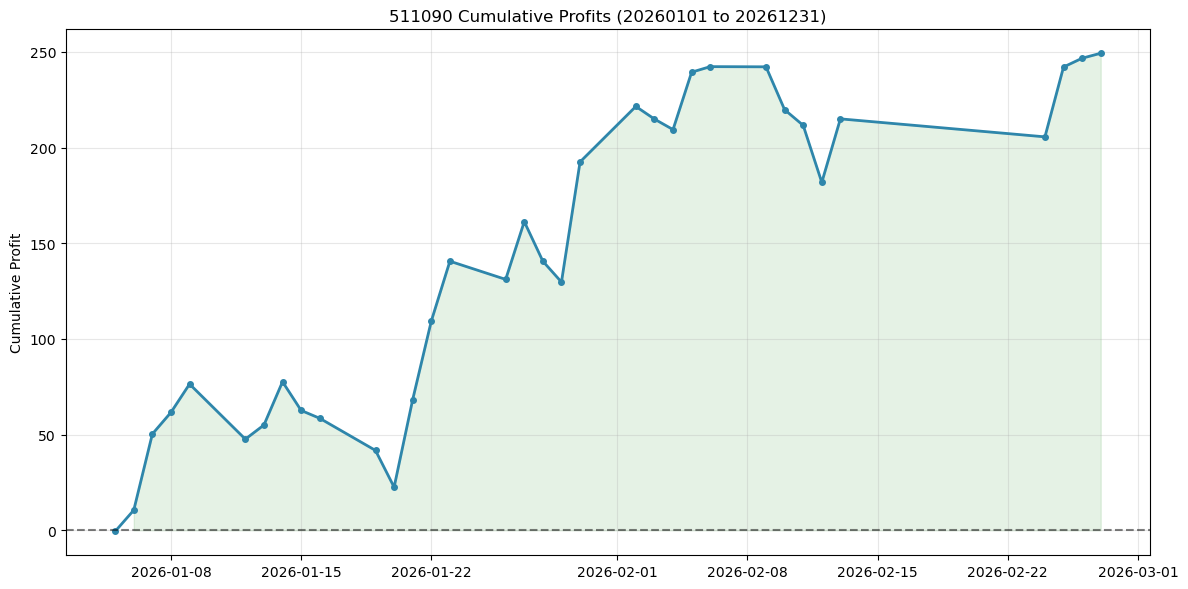


并行回测结果汇总:
{'测试天数': 34, '累计总盈亏': np.float64(249.3), '总成交次数': 1133, '盈利交易次数': 419, '亏损交易次数': 714, '加权每手胜率%': np.float64(36.98), '日均盈亏': np.float64(7.33), '胜率(天)%': 52.94, '盈亏比(日均)': np.float64(1.96), '最大单日盈利': 62.8, '最大单日亏损': -29.8, '每笔交易平均盈利': np.float64(0.22), '加权平均持仓时间(快照)': np.float64(320.74)}


In [206]:
# 导入修复的并行回测模块
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from multi_day_backtest import backtest_summary
# 运行并行回测
result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20260101",
    end_ymd="20261231",
    StrategyClass=StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)
print(summary)

## 延迟回测结果

In [ ]:
from delay_stability_test import batch_delay_stability_test
batch_delay_stability_test(
    instrument_id,
    "20251201",
    "20251231",
    StrategyDemo,
    model_path,
    param_dict,
    [0,1,2,4,8,16,32,64,128,256,512,1024],
    
)

## 保存回测结果

In [92]:
# 导入结果保存工具
from tools.result_saver import save_backtest_results

# 保存回测结果

result_dir = save_backtest_results(
    param_dict=param_dict,
    summary=summary,
    result_df=result_df
)

print(f"回测结果已保存到: {result_dir}")
print("文件夹包含以下文件:")
import os
for file in os.listdir(result_dir):
    print(f"  - {file}")

保存回测结果到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260422_010643
回测结果已保存到: /home/jovyan/work/tactics_demo/backtest_result/518880_delta_v1_adaptive_20260422_010643
文件夹包含以下文件:
  - summary.json
  - daily_results.pkl
  - parameters.json
  - daily_results.csv
  - README.md


In [95]:
from tools import delete_backtest_results_by_date, delete_backtest_results_by_instrument_date
delete_backtest_results_by_date("20260413", dry_run=True)
deleted = delete_backtest_results_by_instrument_date("511520", "20260417", dry_run=False)


[DRY RUN] 总共将删除 0 个文件夹
已删除: /home/jovyan/work/tactics_demo/backtest_result/511520_delta_v1_adaptive_20260417_085159

总共删除了 1 个文件夹


## 单日回测观察

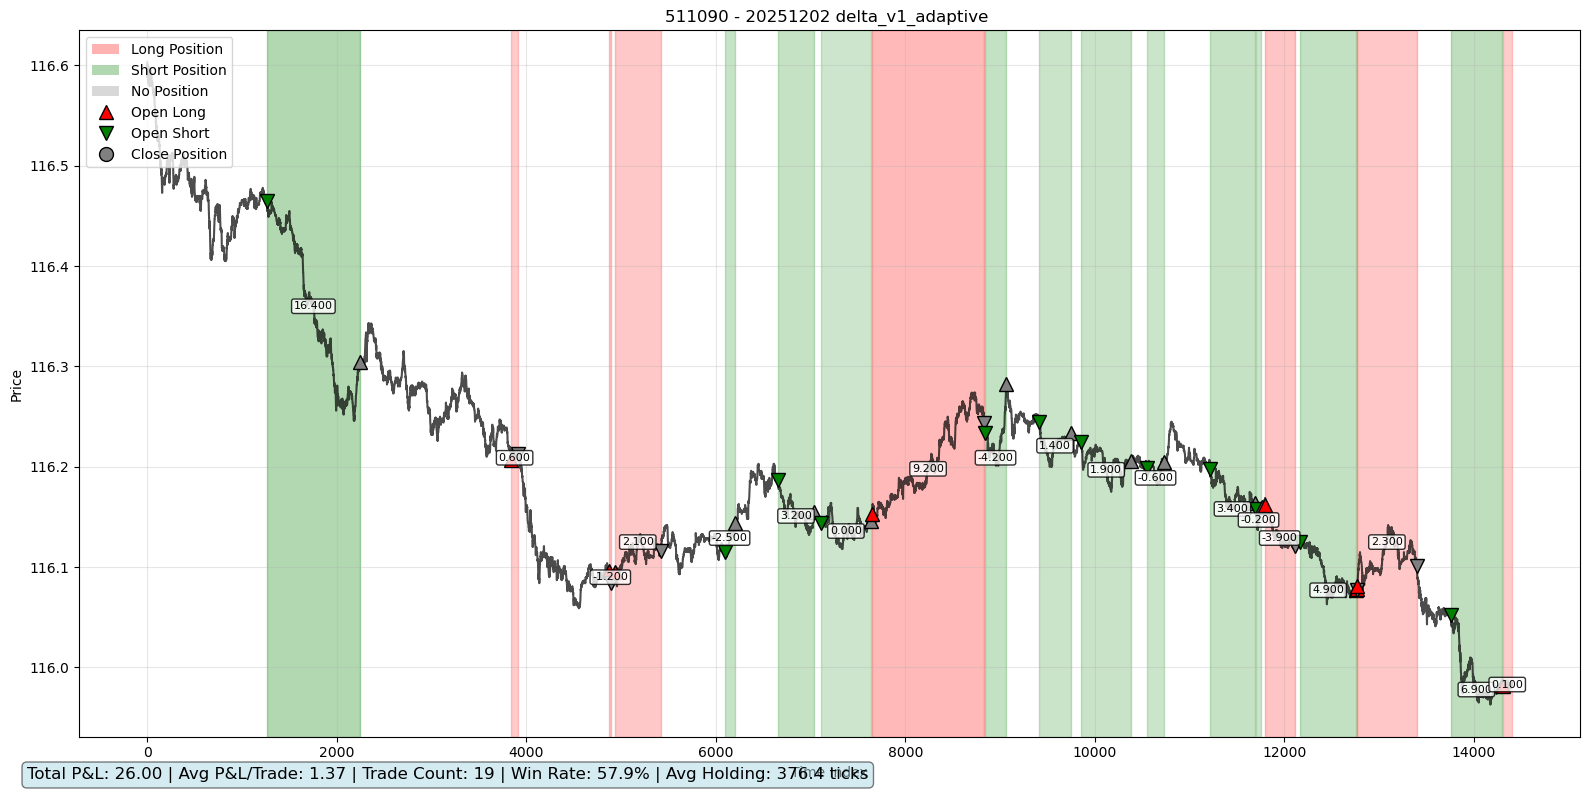

In [202]:
from single_day_backtest import single_day_backtest,plot_delta_history
strategy = StrategyDemo(model_path, param_dict)
hh = single_day_backtest(instrument_id,'20251202',StrategyDemo,model_path,param_dict,official = False)

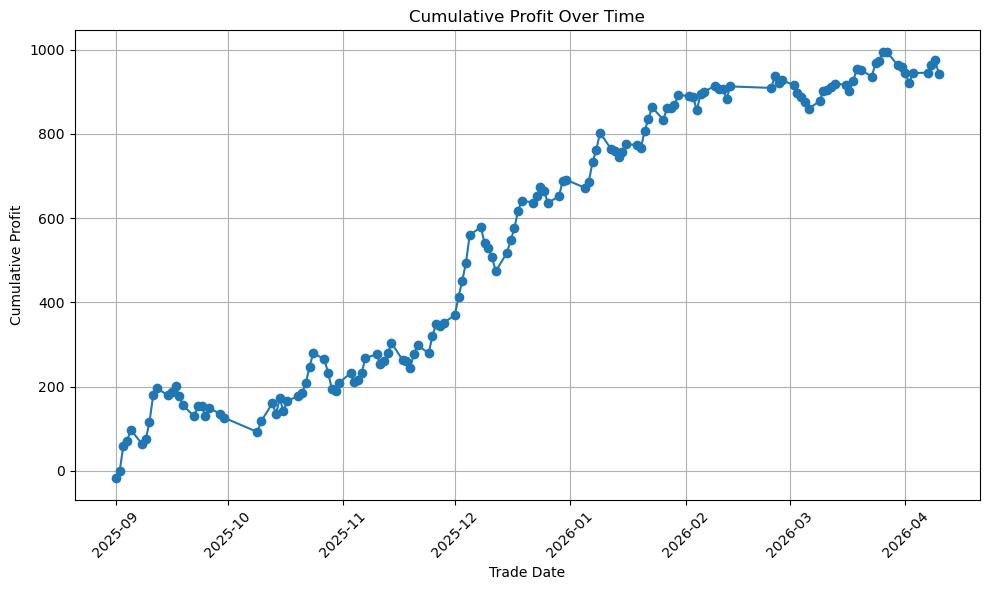

In [20]:
summary = pd.read_csv('/home/jovyan/work/live_trading/511090_20260421_oyyb_01.csv')
# plot cumulative profits

summary['cumulative_profit'] = summary['profits'].cumsum()
summary['trade_ymd'] = pd.to_datetime(summary['trade_ymd'], format='%Y%m%d')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(summary['trade_ymd'], summary['cumulative_profit'], marker='o')
plt.title('Cumulative Profit Over Time')
plt.xlabel('Trade Date')
plt.ylabel('Cumulative Profit')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()
